In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save Model
import joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'StudentsPerformance.csv', 'archive.zip', 'sample_data']


In [ ]:
print(os.listdir())

['.config', 'StudentsPerformance.csv', 'archive.zip', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
# Create Average Score
df["Average Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

# Create Performance column
df["Performance"] = df["Average Score"].apply(
    lambda x: "Good" if x >= 60 else "Poor"
)

# Display first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score,Performance
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Good
1,female,group C,some college,standard,completed,69,90,88,82.333333,Good
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Good
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Poor
4,male,group C,some college,standard,none,76,78,75,76.333333,Good


In [ ]:
lambda x: "Good" if x >= 60 else "Poor"

<function __main__.<lambda>(x)>

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score,Performance
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Good
1,female,group C,some college,standard,completed,69,90,88,82.333333,Good
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Good
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Poor
4,male,group C,some college,standard,none,76,78,75,76.333333,Good


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode all text columns
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

# Check the first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average Score,Performance
0,0,1,1,1,1,72,72,74,72.666667,0
1,0,2,4,1,0,69,90,88,82.333333,0
2,0,1,3,1,1,90,95,93,92.666667,0
3,1,0,0,0,1,47,57,44,49.333333,1
4,1,2,4,1,1,76,78,75,76.333333,0


In [ ]:
# Features (Input)
X = df.drop("Performance", axis=1)

# Target (Output)
y = df["Performance"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 9)
Target Shape: (1000,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (800, 9)
Testing Features : (200, 9)
Training Target  : (800,)
Testing Target   : (200,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       138
           1       1.00      1.00      1.00        62

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
import joblib

# Save the trained model
joblib.dump(model, "student_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
!ls -l

total 256
-rw-r--r-- 1 root root   8907 Jul  7 16:36 archive.zip
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 169225 Jul  7 16:50 student_performance_model.pkl
-rw-r--r-- 1 root root  72036 Jul  7 16:37 StudentsPerformance.csv


In [ ]:
from google.colab import files

files.download("student_performance_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Example student data

sample_student = [[
    0,      # gender (Female=0, Male=1)
    2,      # race/ethnicity
    4,      # parental education
    1,      # lunch
    0,      # test preparation
    80,     # math score
    85,     # reading score
    90,     # writing score
    85.0    # average score
]]

prediction = model.predict(sample_student)

print("Prediction:", prediction)

Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(df["Performance"].unique())

[0 1]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(["Good", "Poor"])

print(le.classes_)

['Good' 'Poor']


In [ ]:
sample_student = [[
    0,      # gender (Female)
    2,      # race/ethnicity
    4,      # parental education
    1,      # lunch
    0,      # test preparation
    80,     # math score
    85,     # reading score
    90,     # writing score
    85.0    # average score
]]

prediction = model.predict(sample_student)

print("Prediction:", prediction)

Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[138   0]
 [  0  62]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       138
           1       1.00      1.00      1.00        62

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
import joblib

joblib.dump(model, "student_performance_model.pkl")
print("Model saved successfully!")

Model saved successfully!


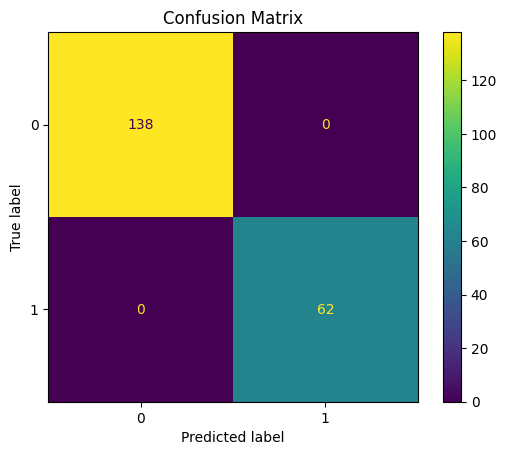

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(model)

RandomForestClassifier(random_state=42)


                       Feature  Importance
8                Average Score    0.443509
7                writing score    0.267361
6                reading score    0.173437
5                   math score    0.097127
3                        lunch    0.006124
0                       gender    0.005102
4      test preparation course    0.003379
1               race/ethnicity    0.002368
2  parental level of education    0.001592


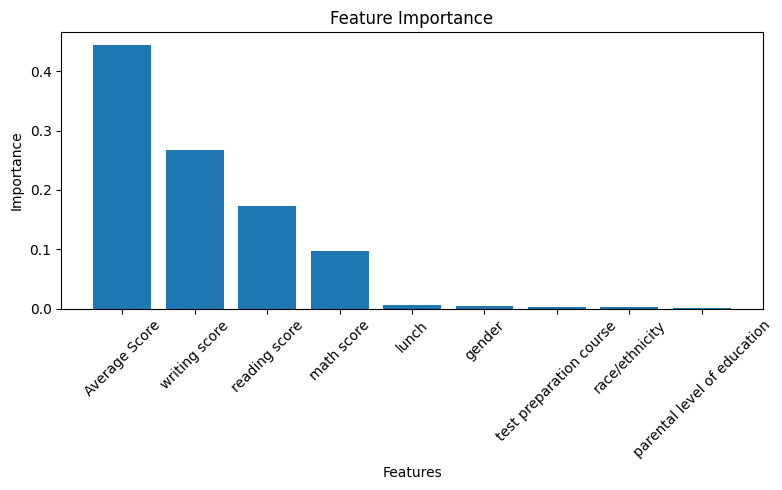

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Display values
print(importance_df)

# Plot
plt.figure(figsize=(8,5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(model, "student_performance_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
print(X.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Average Score'],
      dtype='object')


In [ ]:
print("Good =", le.transform(["Good"])[0])
print("Poor =", le.transform(["Poor"])[0])

Good = 0
Poor = 1
